# **Machine Learning Approach for Stroke Risk Analysis**

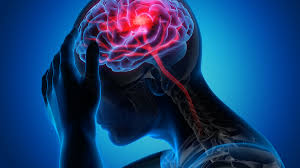

**Project Description:**

**This project predicts the likelihood of stroke in individuals using machine learning by analyzing health-related data to identify high-risk cases. Algorithms used include K-Nearest Neighbors (KNN), Support Vector Classifier (SVC), Decision Tree, Random Forest, Naive Bayes, and XGBoost and the model performance is evaluated based on metrics such as accuracy, precision, recall, and F1-score.**

**IMPORTING SUFFICIENT LIBRARIES**


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

**DATA SET LOADING**

In [ ]:
df=pd.read_csv("/content/healthcare-dataset-stroke-data_manipulated.csv")
df

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4904,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
4905,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
4906,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
4907,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,1


**DATA PREPROCESSING**

In [ ]:
df.drop_duplicates()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4904,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
4905,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
4906,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
4907,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,1


In [ ]:
df.drop(['id'],axis=1,inplace=True)

In [ ]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4904,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
4905,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
4906,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
4907,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,1


In [ ]:
df.isna().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [ ]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64
smoking_status,object


**LABEL ENCODING**

In [ ]:
le=LabelEncoder()

In [ ]:
df['gender']=le.fit_transform(df['gender'])
df['ever_married']=le.fit_transform(df['ever_married'])
df['work_type']=le.fit_transform(df['work_type'])
df['Residence_type']=le.fit_transform(df['Residence_type'])
df['smoking_status']=le.fit_transform(df['smoking_status'])

In [ ]:
df.dtypes

,0
gender,int64
age,float64
hypertension,int64
heart_disease,int64
ever_married,int64
work_type,int64
Residence_type,int64
avg_glucose_level,float64
bmi,float64
smoking_status,int64


In [ ]:
df

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,67.0,0,1,1,2,1,228.69,36.6,1,1
1,1,80.0,0,1,1,2,0,105.92,32.5,2,1
2,0,49.0,0,0,1,2,1,171.23,34.4,3,1
3,0,79.0,1,0,1,3,0,174.12,24.0,2,1
4,1,81.0,0,0,1,2,1,186.21,29.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
4904,0,13.0,0,0,0,4,0,103.08,18.6,0,0
4905,0,81.0,0,0,1,3,1,125.20,40.0,2,0
4906,0,35.0,0,0,1,3,0,82.99,30.6,2,0
4907,1,51.0,0,0,1,2,0,166.29,25.6,1,1


**SEPARATING FEATURES AND TARGETS**

In [ ]:
x=df.iloc[:,:-1]
x

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1,67.0,0,1,1,2,1,228.69,36.6,1
1,1,80.0,0,1,1,2,0,105.92,32.5,2
2,0,49.0,0,0,1,2,1,171.23,34.4,3
3,0,79.0,1,0,1,3,0,174.12,24.0,2
4,1,81.0,0,0,1,2,1,186.21,29.0,1
...,...,...,...,...,...,...,...,...,...,...
4904,0,13.0,0,0,0,4,0,103.08,18.6,0
4905,0,81.0,0,0,1,3,1,125.20,40.0,2
4906,0,35.0,0,0,1,3,0,82.99,30.6,2
4907,1,51.0,0,0,1,2,0,166.29,25.6,1


In [ ]:
y=df.iloc[:,-1]
y

,stroke
0,1
1,1
2,1
3,1
4,1
...,...
4904,0
4905,0
4906,0
4907,1


**SCALING**

In [ ]:
scaler=MinMaxScaler()
x_scaled=scaler.fit_transform(x)
x_scaled

array([[0.5       , 0.81689453, 0.        , ..., 0.80126489, 0.30126002,
        0.33333333],
       [0.5       , 0.97558594, 0.        , ..., 0.23451205, 0.25429553,
        0.66666667],
       [0.        , 0.59716797, 0.        , ..., 0.53600776, 0.27605956,
        1.        ],
       ...,
       [0.        , 0.42626953, 0.        , ..., 0.12865848, 0.2325315 ,
        0.66666667],
       [0.5       , 0.62158203, 0.        , ..., 0.51320284, 0.17525773,
        0.33333333],
       [0.        , 0.53613281, 0.        , ..., 0.13922999, 0.18213058,
        0.        ]])

**TRAIN TEST SPLIT**

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.3,random_state=1)

**MODEL SELECTION**

In [ ]:
knn=KNeighborsClassifier()
sv=SVC()
rf=RandomForestClassifier()
dt=DecisionTreeClassifier(criterion='entropy')
nb=GaussianNB()
xg=XGBClassifier()

**PERFORMANCE MEASURES**

In [ ]:
models=[knn,sv,rf,dt,nb,xg]
for i in models:
  print("____________",i,"____________")
  i.fit(x_train,y_train)
  y_pred=i.predict(x_test)
  print(classification_report(y_test,y_pred))

____________ KNeighborsClassifier() ____________
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1167
           1       0.90      0.77      0.83       306

    accuracy                           0.93      1473
   macro avg       0.92      0.87      0.90      1473
weighted avg       0.93      0.93      0.93      1473

____________ SVC() ____________
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      1167
           1       0.92      0.80      0.86       306

    accuracy                           0.94      1473
   macro avg       0.94      0.89      0.91      1473
weighted avg       0.94      0.94      0.94      1473

____________ RandomForestClassifier() ____________
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1167
           1       1.00      0.90      0.94       306

    accuracy                           0.98      1

In [ ]:
y.value_counts()

,count
stroke,
0,3862
1,1047


**CHANGING IMBALANCED DATASET INTO BALANCED DATASET**

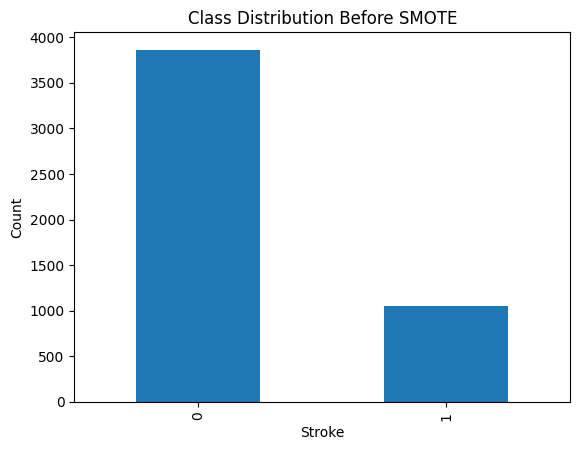

In [ ]:
df['stroke'].value_counts().plot(kind='bar')
plt.title("Class Distribution Before SMOTE")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()


In [ ]:
os=SMOTE(random_state=1)

In [ ]:
x_os,y_os=os.fit_resample(x,y)

In [ ]:
y_os.value_counts()

,count
stroke,
1,3862
0,3862


In [ ]:
x_scaled1=scaler.fit_transform(x_os)

In [ ]:
x_ostrain,x_ostest,y_ostrain,y_ostest=train_test_split(x_scaled1,y_os,test_size=0.3,random_state=1)

In [ ]:
models=[knn,sv,rf,dt,nb,xg]
for i in models:
  print("____________",i,"____________")
  i.fit(x_ostrain,y_ostrain)
  y_pred1=i.predict(x_ostest)
  print(classification_report(y_ostest,y_pred1))

____________ KNeighborsClassifier() ____________
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1153
           1       0.92      0.91      0.91      1165

    accuracy                           0.91      2318
   macro avg       0.91      0.91      0.91      2318
weighted avg       0.91      0.91      0.91      2318

____________ SVC() ____________
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1153
           1       0.96      0.88      0.91      1165

    accuracy                           0.92      2318
   macro avg       0.92      0.92      0.92      2318
weighted avg       0.92      0.92      0.92      2318

____________ RandomForestClassifier() ____________
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1153
           1       0.98      0.93      0.96      1165

    accuracy                           0.96      2

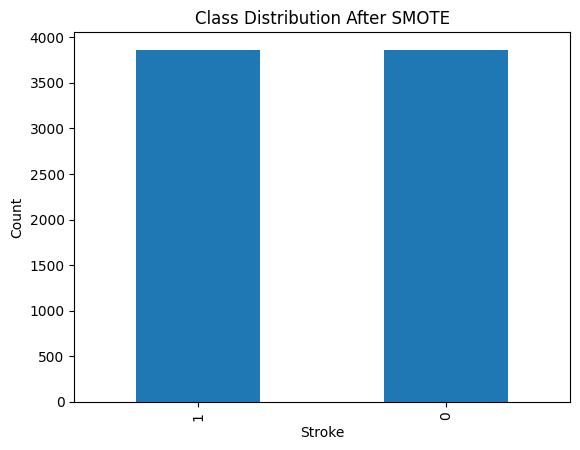

In [ ]:
pd.Series(y_os).value_counts().plot(kind='bar')
plt.title("Class Distribution After SMOTE")
plt.xlabel("Stroke")
plt.ylabel("Count")
plt.show()


**HYPER PARAMETER TUNNING**

In [ ]:
knnparams={'n_neighbors':[3,5,7,9],
           'weights':['uniform','distance'],
           'algorithm':['auto','ball_tree','kd_tree','brute']}
knngrid=GridSearchCV(knn,knnparams,cv=10, scoring='accuracy')
knngrid.fit(x_ostrain,y_ostrain)


GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [ ]:
print(knngrid.best_params_)

{'algorithm': 'auto', 'n_neighbors': 7, 'weights': 'distance'}


In [ ]:
svmparams={'kernel':['linear','poly','rbf','sigmoid'],
           'gamma':['scale','auto'],
           'degree':[3,4,5],
           'C':[1,2,3]}
svmgrid=GridSearchCV(sv,svmparams,cv=10,scoring='accuracy')
svmgrid.fit(x_ostrain,y_ostrain)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': [1, 2, 3], 'degree': [3, 4, 5],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy')

In [ ]:
print(svmgrid.best_params_)

{'C': 3, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}


In [ ]:
nbparams={'var_smoothing':[1,1.5,2,2.5,3]}
nbgrid=GridSearchCV(nb,nbparams,cv=10,scoring='accuracy')
nbgrid.fit(x_ostrain,y_ostrain)

GridSearchCV(cv=10, estimator=GaussianNB(),
             param_grid={'var_smoothing': [1, 1.5, 2, 2.5, 3]},
             scoring='accuracy')

In [ ]:
print(nbgrid.best_params_)

{'var_smoothing': 1}


In [ ]:
dtparams={'criterion':['gini','entropy','log_loss'],
          'splitter':['best','random'],
          'max_depth':[1,2,3,4,5,]}
dtgrid=GridSearchCV(dt,dtparams,cv=10,scoring='accuracy')
dtgrid.fit(x_ostrain,y_ostrain)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(criterion='entropy'),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [ ]:
print(dtgrid.best_params_)

{'criterion': 'gini', 'max_depth': 5, 'splitter': 'best'}


In [ ]:
rfparams={'n_estimators':[100,101,102,103],
          'criterion':['gini','entropy','log_loss'],
          'max_depth':[1,2,3,4,5]}
rfgrid=GridSearchCV(rf,rfparams,cv=10,scoring='accuracy')
rfgrid.fit(x_ostrain,y_ostrain)

GridSearchCV(cv=10, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5],
                         'n_estimators': [100, 101, 102, 103]},
             scoring='accuracy')

In [ ]:
print(rfgrid.best_params_)

In [ ]:
xgparams={'n_estimators':[100,101,102,103],
          'learning_rate':[1,1.5,2,2.5,3],
          'subsample':[1,1.5,2,2.5,3]}
xggrid=GridSearchCV(xg,xgparams,cv=10,scoring='accuracy')
xggrid.fit(x_ostrain,y_ostrain)

GridSearchCV(cv=10,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=No...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [1, 1.5, 2, 2.5, 3],
                         'n_estimators': [100, 101, 102, 103],
                         'subsample': [1, 1.5, 2, 2.5, 3]},
             scoring='accuracy')

In [ ]:
print(xggrid.best_params_)

{'learning_rate': 1, 'n_estimators': 103, 'subsample': 1}


In [ ]:
knn1=KNeighborsClassifier(n_neighbors=7,weights='distance',algorithm='auto')
svm1=SVC(kernel='poly',gamma='scale',degree=4,C=3)
nb1=GaussianNB(var_smoothing=1)
dt1=DecisionTreeClassifier(criterion='gini',splitter='best',max_depth=5)
rf1=RandomForestClassifier(n_estimators=102,criterion='log_loss',max_depth=5)
xg1=XGBClassifier(n_estimators=103,learning_rate=1,subsample=1)

In [ ]:
models1=[knn1,svm1,nb,dt1,rf1,xg1]
for model in models1:
  print('________',model,'________')
  model.fit(x_ostrain,y_ostrain)
  y_pred1=model.predict(x_ostest)
  print(classification_report(y_ostest,y_pred1))

________ KNeighborsClassifier(n_neighbors=7, weights='distance') ________
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      1153
           1       0.93      0.93      0.93      1165

    accuracy                           0.93      2318
   macro avg       0.93      0.93      0.93      2318
weighted avg       0.93      0.93      0.93      2318

________ SVC(C=3, degree=4, kernel='poly') ________
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1153
           1       0.96      0.89      0.93      1165

    accuracy                           0.93      2318
   macro avg       0.93      0.93      0.93      2318
weighted avg       0.93      0.93      0.93      2318

________ GaussianNB() ________
              precision    recall  f1-score   support

           0       0.84      0.93      0.88      1153
           1       0.93      0.82      0.87      1165

    accuracy             

**FEATURE SELECTION**

In [ ]:
df.corr()['stroke']

,stroke
gender,0.056234
age,0.363111
hypertension,0.450756
heart_disease,0.192978
ever_married,0.213750
work_type,-0.075605
Residence_type,-0.000071
avg_glucose_level,0.716379
bmi,0.195772
smoking_status,0.110867


In [ ]:
x1=x.drop(['work_type','Residence_type'],axis=1)

In [ ]:
x1_train,x1_test,y1_train,y1_test=train_test_split(x1,y,test_size=0.3,random_state=1)

In [ ]:
for model in models1:
  print('_________',model,'_________')
  model.fit(x1_train,y1_train)
  y1_pred=model.predict(x1_test)
  print(classification_report(y1_test,y1_pred))

_________ XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=103,
              n_jobs=None, num_parallel_tree=None, ...) _________
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1167
           1       0.96      0.89      0.93       306

    accuracy                           0.97      1473
   ma

In [ ]:
os1=SMOTE(random_state=1)

In [ ]:
x1_os,y1_os=os1.fit_resample(x1,y)

In [ ]:
y1_os.value_counts()

,count
stroke,
1,3862
0,3862


In [ ]:
x_scaled2=scaler.fit_transform(x1_os)

In [ ]:
x1_ostrain,x1_ostest,y1_ostrain,y1_ostest=train_test_split(x_scaled2,y1_os,test_size=0.3,random_state=1)

In [ ]:
models=[knn,sv,rf,dt,nb,xg]
for i in models:
  print("____________",i,"____________")
  i.fit(x1_ostrain,y1_ostrain)
  y_pred1=i.predict(x1_ostest)
  print(classification_report(y1_ostest,y_pred1))

____________ KNeighborsClassifier() ____________
              precision    recall  f1-score   support

           0       0.93      0.92      0.92      1153
           1       0.92      0.93      0.93      1165

    accuracy                           0.93      2318
   macro avg       0.93      0.93      0.93      2318
weighted avg       0.93      0.93      0.93      2318

____________ SVC() ____________
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1153
           1       0.96      0.88      0.92      1165

    accuracy                           0.92      2318
   macro avg       0.92      0.92      0.92      2318
weighted avg       0.92      0.92      0.92      2318

____________ RandomForestClassifier() ____________
              precision    recall  f1-score   support

           0       0.94      0.98      0.96      1153
           1       0.98      0.94      0.96      1165

    accuracy                           0.96      2

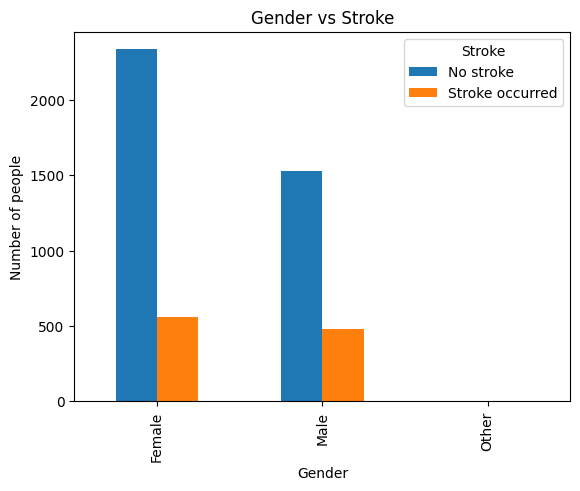

In [ ]:
gender_stroke = df.groupby(['gender', 'stroke']).size().unstack()
gender_stroke.index = ['Female', 'Male', 'Other']
gender_stroke.plot(kind='bar')
plt.title("Gender vs Stroke")
plt.xlabel("Gender")
plt.ylabel("Number of people")
plt.legend(title='Stroke', labels=['No stroke', 'Stroke occurred'])
plt.show()

In [ ]:
model_names = ['KNN', 'SVM', 'Random Forest', 'Decision Tree', 'Naive Bayes', 'XGBoost']
scores = []

for model in models:
    model.fit(x1_ostrain, y1_ostrain)
    y_pred = model.predict(x1_ostest)
    report = classification_report(y1_ostest, y_pred, output_dict=True)
    scores.append(report['accuracy'])

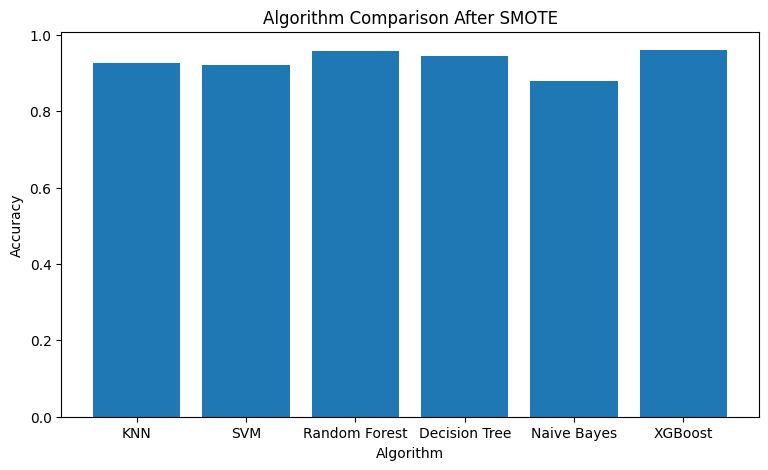

In [ ]:
plt.figure(figsize=(9,5))
plt.bar(model_names, scores)
plt.title("Algorithm Comparison After SMOTE")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy")
plt.show()

**Random Forest and XGBoost demonstrated superior performance compared to other classification algorithms.**